In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("../data/fire_db.csv")


=== CLASS BALANCE ===
any_evacuation
False    14672
True       531
Name: count, dtype: int64
any_evacuation
False    0.965073
True     0.034927
Name: proportion, dtype: float64

=== EVAC RATE BY FN INDICATOR ===
fn_indicator
False    0.033481
True     0.115242
Name: any_evacuation, dtype: float64

=== FIRE_CAUSE VALUE COUNTS ===
fire_cause
natural                  12585
human                     1963
unknown                    588
human_prescribed_burn       67
Name: count, dtype: int64

=== FIRE_TYPE VALUE COUNTS ===
fire_type
unknown             8569
wildfire            2268
fire                1755
ifr                 1695
crown                360
surface              315
ofr                  102
ground                50
pb                    19
prescribed burn       15
type 5                14
mutual aid            11
type 3                 6
req for assist         6
type 4                 4
1                      4
type 1                 3
forest                 2
type 2         

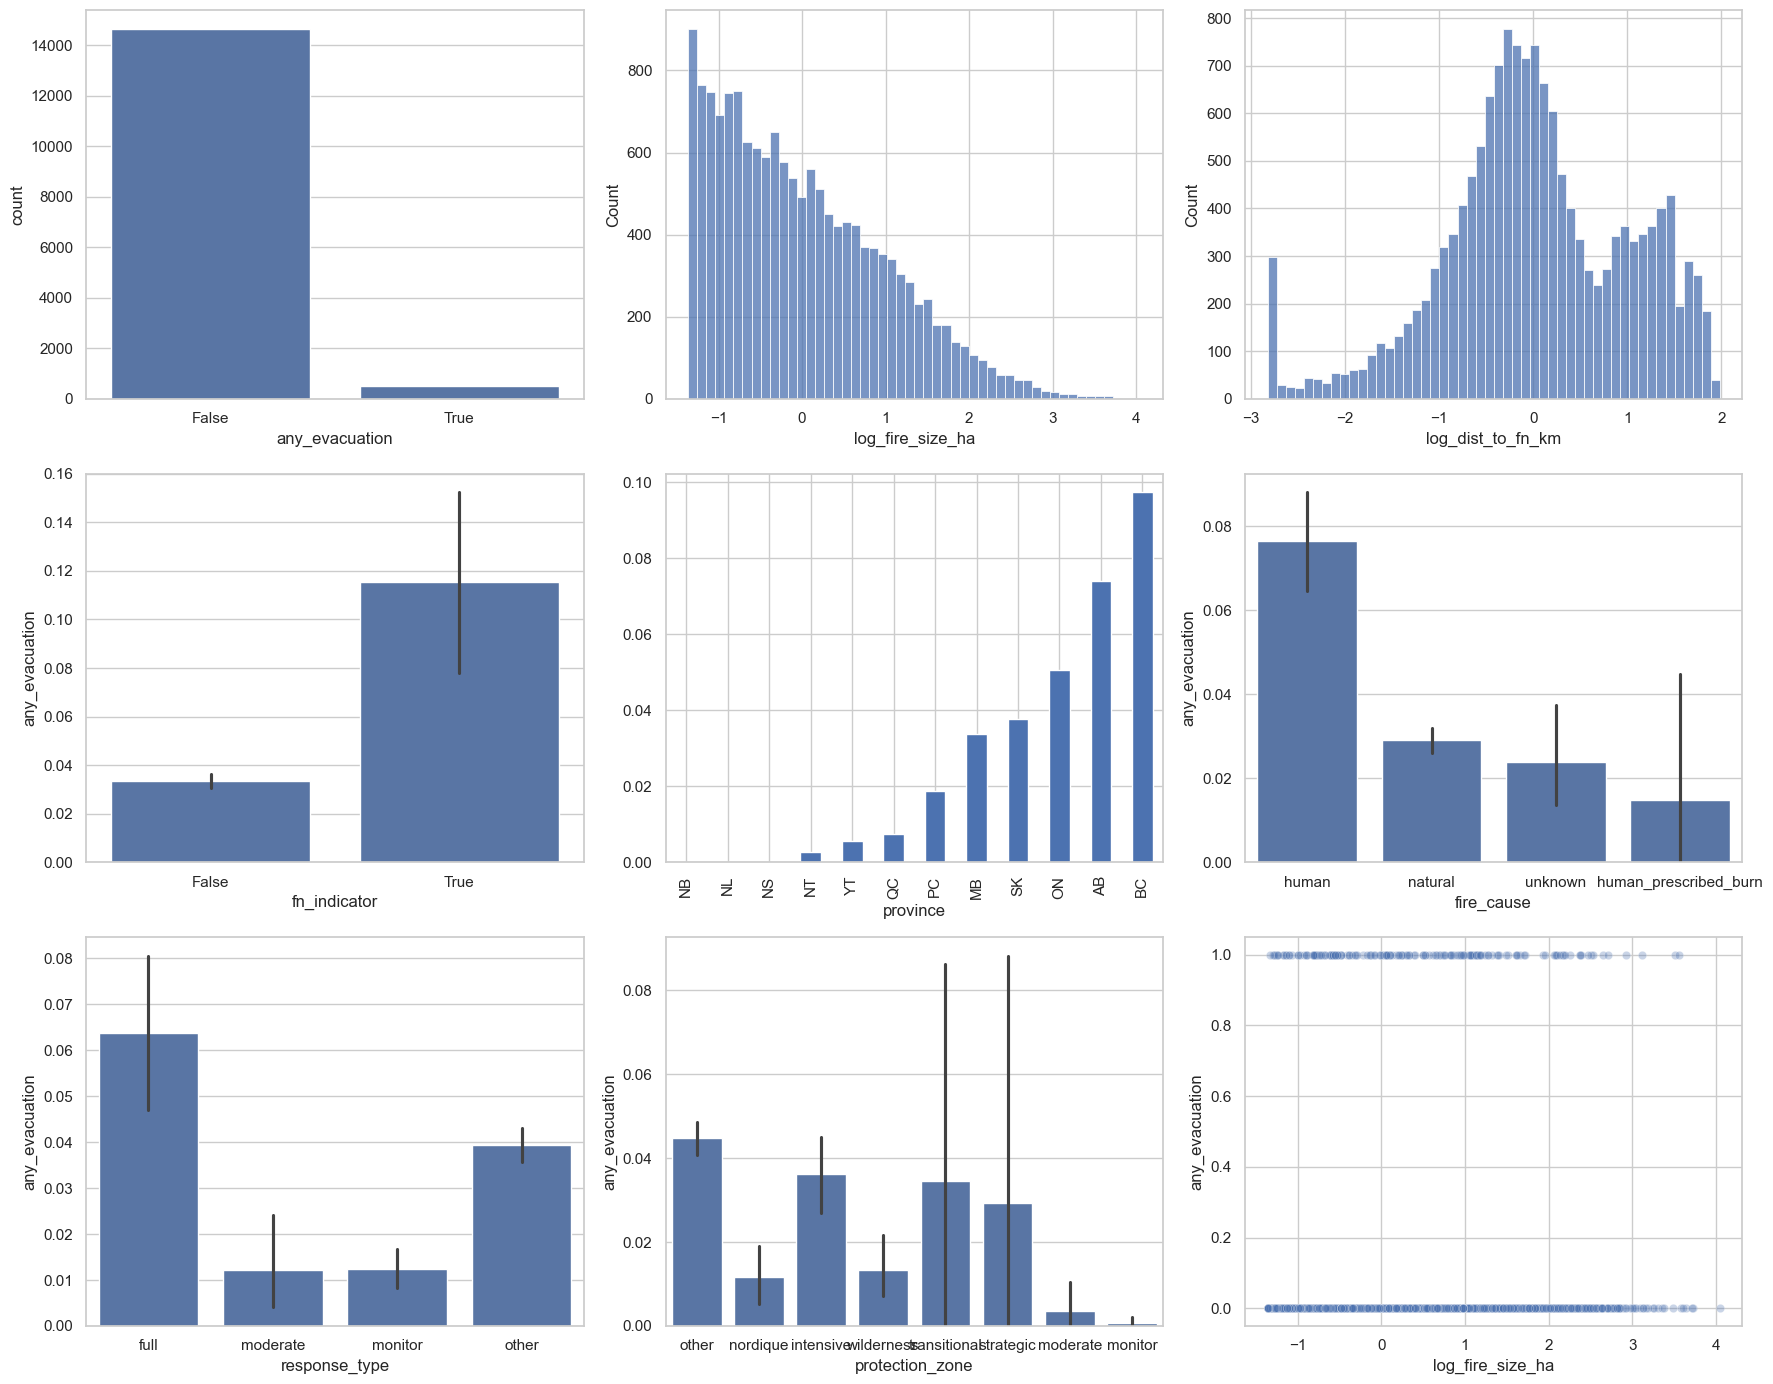

In [3]:
# --- BASIC SETUP ---
sns.set(style="whitegrid")

# --- BASIC STATS ---
# print("\n=== BASIC INFO ===")
# print(df.shape)
# print(df.dtypes)
# print(df.describe(include='all'))

print("\n=== CLASS BALANCE ===")
print(df['any_evacuation'].value_counts())
print(df['any_evacuation'].value_counts(normalize=True))

print("\n=== EVAC RATE BY FN INDICATOR ===")
print(df.groupby('fn_indicator')['any_evacuation'].mean())

# --- CATEGORICAL DISTRIBUTIONS ---
cat_cols = ['fire_cause','fire_type','response_type','protection_zone']
for col in cat_cols:
    print(f"\n=== {col.upper()} VALUE COUNTS ===")
    print(df[col].value_counts(dropna=False))

# --- Evac Rates per category ---
for col in cat_cols:
    print(f"\n=== EVAC RATE BY {col.upper()} ===")
    print(df.groupby(col)['any_evacuation'].mean().sort_values())

# --- NUMERICAL CORRELATIONS ---
num_cols = ['log_fire_size_ha','log_dist_to_fn_km','n_fn_20km']
print("\n=== CORRELATIONS ===")
print(df[num_cols + ['any_evacuation']].corr())

# --- PLOTTING ---
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# Class balance
sns.countplot(data=df, x='any_evacuation', ax=axes[0,0])

# Fire size distribution
sns.histplot(df['log_fire_size_ha'], bins=50, ax=axes[0,1])

# Distance to FN
sns.histplot(df['log_dist_to_fn_km'], bins=50, ax=axes[0,2])

# Evac vs FN
sns.barplot(data=df, x='fn_indicator', y='any_evacuation', ax=axes[1,0])

# Evac vs province
df.groupby('province')['any_evacuation'].mean().sort_values().plot(kind='bar', ax=axes[1,1])

# Evac vs fire cause
sns.barplot(data=df, x='fire_cause', y='any_evacuation', ax=axes[1,2])

# Evac vs response type
sns.barplot(data=df, x='response_type', y='any_evacuation', ax=axes[2,0])

# Evac vs protection zone
sns.barplot(data=df, x='protection_zone', y='any_evacuation', ax=axes[2,1])

# Scatter size vs evac
sns.scatterplot(data=df.sample(min(5000,len(df))), x='log_fire_size_ha', y='any_evacuation', alpha=0.3, ax=axes[2,2])

plt.tight_layout()
plt.show()

In [4]:
evac_db = pd.read_csv("../data/Canadian_Wildfire_Evacuation_Data.csv")

In [5]:
len(evac_db)

1043

% of evacuations on FN reserves

In [6]:
len(evac_db[evac_db['FN_Reserve'] == 'yes']) / len(evac_db)

0.3624161073825503

In [7]:
nfdb = pd.read_csv("../data/NFDB_point.csv")
len(nfdb)

15206

In [8]:
len(df), df['any_evacuation'].sum()

(15203, np.int64(531))

In [9]:
df.columns

Index(['province', 'latitude', 'longitude', 'fire_cause', 'fire_type',
       'response_type', 'protection_zone', 'fn_indicator', 'n_fn_20km',
       'any_evacuation', 'log_fire_size_ha', 'log_dist_to_fn_km'],
      dtype='str')

In [10]:
df['province'].nunique()

12

In [11]:
df.protection_zone.nunique()

8

In [13]:
df.fn_indicator.sum()

np.int64(269)